# Recurrent Networks: RNN, LSTM and GRU

**Applied ML in Production · Bonus 3 of 4**

---

Bonus 2 gave the network a grid and it exploited the grid. This notebook gives it
a **sequence** — where order carries the meaning and the useful clue may have
arrived fifty steps ago.

Sequences are everywhere in the kind of work this module is about: a customer's
transaction history, a machine's sensor trace, a patient's visits, a month of
loan applications, and every sentence anyone has ever written.

We build a recurrent cell by hand, measure the **vanishing gradient** that limits
it, then see how the LSTM's gates fix it — on the benchmark that was invented to
prove the point.

## How to work through this

Type the code. Everything trains in seconds; the whole notebook runs in about a
minute on a laptop CPU.

Run each cell, read the output, then read the commentary. If a cell errors, run
from the top.

## Learning objectives

After this session you will be able to:

- Say what makes sequence data different, and shape it into `(batch, time, features)`.
- Implement a recurrent cell by hand and explain weight sharing across time.
- Use `nn.RNN`, `nn.LSTM` and `nn.GRU`, and read their outputs.
- **Measure** the vanishing gradient and explain what it costs.
- Describe the LSTM's cell state and three gates, and the GRU's two.
- Compare all three on a long-range task and on forecasting, against a naive baseline.
- Decide when a recurrent model is the right tool today.

In [1]:
%matplotlib inline

import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__)

torch 2.13.0


---

## 1. What makes a sequence different

A tabular row is a set of facts about one thing. A sequence is a list of
observations where **position matters**: "declined, declined, approved" is not the
same customer story as "approved, declined, declined".

Three consequences for the modelling.

**Order carries information**, so shuffling the columns of a tabular model is
harmless and shuffling a sequence destroys it.

**Length varies.** One customer has 3 transactions, another has 300. Dense layers
need a fixed input size; recurrence does not.

**The relevant clue can be far away.** The reason an account defaults in December
may be something that happened in March.

PyTorch expects sequences shaped `(batch, time, features)` — with
`batch_first=True`, which is not the default and is the source of most confusion
in this corner of the library.

In [2]:
batch, time_steps, features = 4, 6, 1
example = torch.randn(batch, time_steps, features)
print("a batch of sequences:", tuple(example.shape), "= (batch, time, features)")
print("one sequence:", example[0].squeeze().numpy().round(2))

a batch of sequences: (4, 6, 1) = (batch, time, features)
one sequence: [-1.13 -1.15 -0.25 -0.43  0.85  0.69]


---

## 2. A recurrent cell, by hand

A recurrent network reads one step at a time and carries a **hidden state** — a
summary of everything it has seen so far.

$$ h_t = \tanh(W_x x_t + W_h h_{t-1} + b) $$

The same weights are used at every step. That is the sequence equivalent of the
CNN's weight sharing: one small set of parameters, applied everywhere.

In [3]:
def simple_rnn(sequence, W_x, W_h, b):
    """Run a vanilla RNN over one sequence and return every hidden state."""
    hidden = np.zeros(W_h.shape[0])
    states = []
    for x in sequence:                       # one step at a time — this loop IS the recurrence
        hidden = np.tanh(W_x * x + W_h @ hidden + b)
        states.append(hidden.copy())
    return np.array(states)


rng = np.random.default_rng(0)
HIDDEN = 3
W_x = rng.normal(0, 0.8, HIDDEN)
W_h = rng.normal(0, 0.8, (HIDDEN, HIDDEN))
b = np.zeros(HIDDEN)

sequence = np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.0])      # a pulse, then silence
states = simple_rnn(sequence, W_x, W_h, b)

print("hidden state after each step:")
for step, state in enumerate(states):
    print(f"  t={step}  {state.round(3)}")

hidden state after each step:
  t=0  [ 0.1   -0.105  0.472]
  t=1  [ 0.188 -0.236 -0.033]
  t=2  [ 0.107  0.036 -0.073]
  t=3  [-0.027  0.178 -0.128]
  t=4  [-0.115  0.176 -0.065]
  t=5  [-0.104  0.05   0.026]


Every number after `t=0` is an echo. The input is zero from `t=1` onward, so
without the pulse the hidden state would stay exactly zero — what you see is the
pulse reverberating through the recurrent weights, and shrinking as it goes: the
state's magnitude falls from 0.49 to 0.12 across five steps.

That fading is the whole story of this notebook. A vanilla RNN remembers, but the
memory decays, and how fast it decays is not something you control.

### The same thing in PyTorch

In [4]:
rnn = nn.RNN(input_size=1, hidden_size=8, batch_first=True)

sequences = torch.randn(4, 6, 1)             # 4 sequences, 6 steps, 1 feature
output, final_hidden = rnn(sequences)

print("output      ", tuple(output.shape), "-> the hidden state at EVERY step")
print("final_hidden", tuple(final_hidden.shape), "-> the hidden state at the LAST step")
print("\nthey agree:", torch.allclose(output[:, -1], final_hidden[0]))

output       (4, 6, 8) -> the hidden state at EVERY step
final_hidden (1, 4, 8) -> the hidden state at the LAST step

they agree: True


Use `output` when every step needs a prediction (tagging each word in a sentence).
Use the last state when the whole sequence gets one prediction (is this customer
about to churn?). We do the second.

---

## 3. The vanishing gradient, measured

Training a recurrent network means backpropagating through every time step. Each
step multiplies the gradient by the recurrent weights and the tanh derivative,
and repeated multiplication of numbers below 1 collapses toward zero.

Rather than assert it, measure it: how much does the network's final output depend
on the input at each time step?

In [5]:
def gradient_by_timestep(cell, length):
    """|d(final output) / d(input at time t)| for every t."""
    torch.manual_seed(0)
    layer = {"RNN": nn.RNN, "LSTM": nn.LSTM}[cell](1, 32, batch_first=True)
    head = nn.Linear(32, 1)

    x = torch.randn(1, length, 1, requires_grad=True)
    output, _ = layer(x)
    head(output[:, -1]).sum().backward()
    return x.grad.abs()[0, :, 0].numpy()


for length in [10, 50, 200]:
    gradients = gradient_by_timestep("RNN", length)
    print(f"RNN, length {length:>3}: gradient at the first step {gradients[0]:.2e}, "
          f"at the last step {gradients[-1]:.2e}")

RNN, length  10: gradient at the first step 1.20e-04, at the last step 4.40e-02
RNN, length  50: gradient at the first step 1.59e-12, at the last step 4.69e-02
RNN, length 200: gradient at the first step 0.00e+00, at the last step 4.72e-02


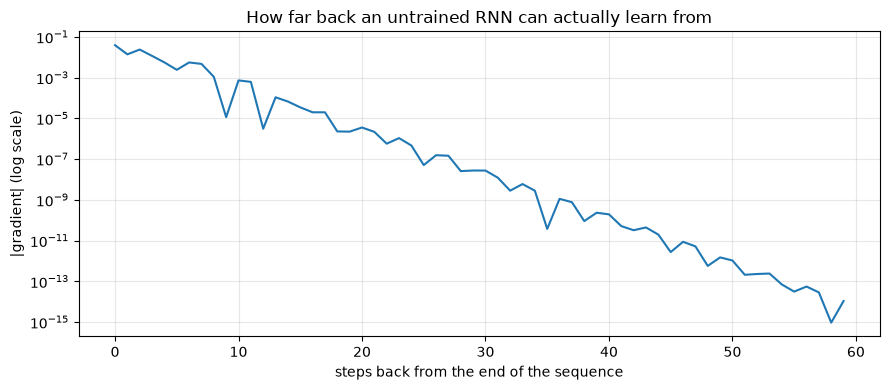

In [6]:
gradients = gradient_by_timestep("RNN", 60)

plt.semilogy(gradients[::-1])
plt.xlabel("steps back from the end of the sequence")
plt.ylabel("|gradient| (log scale)")
plt.title("How far back an untrained RNN can actually learn from")
plt.tight_layout()
plt.show()

Note the log scale. Ten steps back the gradient is already about 2% of its value
at the final step; twenty steps back, a ten-thousandth; forty steps back, a
billionth.

The network is not refusing to learn long-range patterns out of stubbornness. **It
receives no signal about them at all.** Anything more than a few dozen steps in the
past is, gradient-wise, invisible.

(The same measurement on an untrained LSTM looks similar, which is worth knowing:
the LSTM's advantage is not that its gradients never shrink, but that it can
*learn* a path that keeps them alive — which is what the gates are for.)

---

## 4. LSTM and GRU: memory with a switch

The **LSTM** (long short-term memory, 1997) adds a second piece of state — the
**cell state** — that travels along the sequence with only gentle, additive
edits. Three learned gates decide what happens to it at each step.

| Gate | Question it answers | Effect |
|------|--------------------|--------|
| **Forget** | What should I drop from memory? | Multiplies the cell state, element by element |
| **Input** | What from this step is worth storing? | Adds new candidate values into the cell state |
| **Output** | What part of memory is relevant right now? | Controls what the hidden state exposes |

The important structural detail is that the cell state is updated by
multiplication with the forget gate and *addition* of new content, rather than by
being squashed through a tanh every step. If the forget gate stays near 1, a value
can travel a hundred steps almost unchanged — and so can the gradient.

The **GRU** (2014) does the same job with two gates and no separate cell state.
Fewer parameters, faster, usually just as good.

| | Vanilla RNN | LSTM | GRU |
|---|---|---|---|
| **State** | hidden | hidden + cell | hidden |
| **Gates** | none | 3 | 2 |
| **Parameters** (per unit) | 1× | ~4× | ~3× |
| **Long-range memory** | poor | good | good |
| **When to reach for it** | very short sequences, teaching | the default for long sequences | the default when you want speed |

In [7]:
for name, layer in [("RNN ", nn.RNN(1, 32, batch_first=True)),
                    ("LSTM", nn.LSTM(1, 32, batch_first=True)),
                    ("GRU ", nn.GRU(1, 32, batch_first=True))]:
    print(f"{name}: {sum(p.numel() for p in layer.parameters()):,} parameters "
          f"for the same 32 hidden units")

RNN : 1,120 parameters for the same 32 hidden units
LSTM: 4,480 parameters for the same 32 hidden units
GRU : 3,360 parameters for the same 32 hidden units


---

## 5. The benchmark that settled it — the adding problem

This task comes from the original LSTM paper. Each sequence has two channels: a
random value, and a marker that is 1 at exactly two positions. The network must
output the **sum of the two marked values** — which requires holding one number
in memory until the other arrives.

Guessing the average scores about 0.167 mean squared error. Anything near that is
a failure.

In [8]:
def adding_problem(n_sequences, length, seed=0):
    generator = torch.Generator().manual_seed(seed)
    values = torch.rand(n_sequences, length, 1, generator=generator)
    markers = torch.zeros(n_sequences, length, 1)

    for row in range(n_sequences):
        positions = torch.randperm(length, generator=generator)[:2]
        markers[row, positions, 0] = 1.0

    x = torch.cat([values, markers], dim=2)          # (batch, time, 2)
    y = (values * markers).sum(dim=1)                # the target sum
    return x, y


x_demo, y_demo = adding_problem(1, 8, seed=3)
print("values :", x_demo[0, :, 0].numpy().round(2))
print("markers:", x_demo[0, :, 1].numpy().astype(int))
print("target :", y_demo.item().__round__(3), "= sum of the two marked values")

values : [0.   0.11 0.29 0.03 0.47 0.06 0.77 0.74]
markers: [0 1 0 0 0 1 0 0]


target : 0.166 = sum of the two marked values


In [9]:
class Recurrent(nn.Module):
    def __init__(self, cell, input_size=2, hidden=32):
        super().__init__()
        layer = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[cell]
        self.recurrent = layer(input_size, hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        output, _ = self.recurrent(x)
        return self.head(output[:, -1])          # one prediction per sequence


def train_on_adding(cell, length, epochs=20):
    torch.manual_seed(0)
    x_train, y_train = adding_problem(3000, length, seed=0)
    x_test, y_test = adding_problem(600, length, seed=1)

    model = Recurrent(cell)
    optimiser = torch.optim.Adam(model.parameters(), lr=5e-3)
    loss_function = nn.MSELoss()
    loader = DataLoader(TensorDataset(x_train, y_train), batch_size=64, shuffle=True)

    started = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in loader:
            optimiser.zero_grad()
            loss_function(model(batch_x), batch_y).backward()
            optimiser.step()

    model.eval()
    with torch.no_grad():
        error = loss_function(model(x_test), y_test).item()
    return error, time.perf_counter() - started


scores = {}
for length in [20, 50]:
    for cell in ["RNN", "LSTM", "GRU"]:
        error, seconds = train_on_adding(cell, length)
        scores[(cell, length)] = error
        print(f"length {length:>3}  {cell:<5} MSE {error:.4f}   ({seconds:.0f}s)")
    print()

print("guessing the average would score about 0.167")

length  20  RNN   MSE 0.0826   (1s)


length  20  LSTM  MSE 0.0018   (2s)


length  20  GRU   MSE 0.0004   (2s)



length  50  RNN   MSE 0.1634   (1s)


length  50  LSTM  MSE 0.0043   (4s)


length  50  GRU   MSE 0.0008   (3s)

guessing the average would score about 0.167


At **length 20** the vanilla RNN is already struggling (0.08) while the LSTM and
GRU have essentially solved the task.

At **length 50** the RNN scores 0.16 — indistinguishable from guessing the
average. It has learned nothing at all. The LSTM and GRU are still near zero
error.

That is the vanishing gradient from section 3, in a practical consequence rather
than a plot. The gates are not a refinement; they are what makes long-range
learning possible.

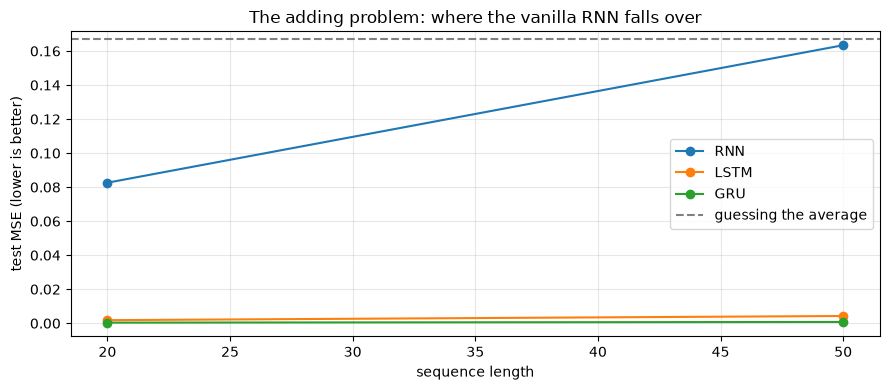

In [10]:
lengths = [20, 50]
fig, ax = plt.subplots()
for cell in ["RNN", "LSTM", "GRU"]:
    ax.plot(lengths, [scores[(cell, length)] for length in lengths], marker="o", label=cell)
ax.axhline(0.167, linestyle="--", color="grey", label="guessing the average")
ax.set_xlabel("sequence length")
ax.set_ylabel("test MSE (lower is better)")
ax.set_title("The adding problem: where the vanilla RNN falls over")
ax.legend()
plt.tight_layout()
plt.show()

> **A caution about benchmarks.** On easier tasks — "remember the first value of a
> noisy sequence" — a vanilla RNN often matches or beats an LSTM at a small
> training budget, because it has a quarter of the parameters and learns faster.
> The LSTM's advantage appears specifically when the task requires *selective*,
> long-range memory. Choose the architecture from the task, and always measure.

---

## 6. Forecasting, with a baseline

The most common business use of these models is forecasting. And the most common
mistake is reporting an impressive-looking error without comparing it to the naive
prediction: **tomorrow will look like today**.

In [11]:
steps = np.arange(600)
series = (np.sin(steps * 0.1) + 0.3 * np.sin(steps * 0.037)
          + np.random.normal(0, 0.1, len(steps)))

WINDOW = 20
windows = np.stack([series[i:i + WINDOW] for i in range(len(series) - WINDOW)])
targets = series[WINDOW:]

split = int(0.8 * len(windows))
x_train = torch.tensor(windows[:split], dtype=torch.float32).unsqueeze(-1)
x_test = torch.tensor(windows[split:], dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(targets[:split], dtype=torch.float32).unsqueeze(-1)
y_test = torch.tensor(targets[split:], dtype=torch.float32).unsqueeze(-1)

loss_function = nn.MSELoss()
print(f"{len(x_train)} training windows of {WINDOW} steps\n")
print(f"baseline — predict the mean:       MSE {loss_function(torch.full_like(y_test, y_train.mean()), y_test):.4f}")
print(f"baseline — predict the last value: MSE {loss_function(x_test[:, -1], y_test):.4f}")

464 training windows of 20 steps

baseline — predict the mean:       MSE 0.5561
baseline — predict the last value: MSE 0.0288


In [12]:
for cell in ["RNN", "LSTM", "GRU"]:
    torch.manual_seed(0)
    model = Recurrent(cell, input_size=1)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-2)
    loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)

    for epoch in range(25):
        model.train()
        for batch_x, batch_y in loader:
            optimiser.zero_grad()
            loss_function(model(batch_x), batch_y).backward()
            optimiser.step()

    model.eval()
    with torch.no_grad():
        print(f"{cell:<5} MSE {loss_function(model(x_test), y_test):.4f}")

RNN   MSE 0.0249


LSTM  MSE 0.0176


GRU   MSE 0.0194


The naive "same as last step" baseline scores 0.0288. The LSTM reaches 0.0176 — a
real improvement of about 40%, on a signal that genuinely has structure a window
can capture.

Session 1's discipline applies unchanged: **a forecasting model that cannot beat
last-value carry-forward has not earned its deployment.** Many published ones
cannot, because nobody checked.

> **On the loan data.** You might expect us to forecast the monthly default rate
> from sessions 8's production stream. We deliberately do not: 24 monthly
> observations is nowhere near enough to fit a recurrent network, and the honest
> tools there are the ones session 8 used — a baseline rate, a drift test, and a
> conversation. Knowing when *not* to reach for a sequence model is part of the
> skill.

---

## 7. Practical matters

**Variable lengths.** Real sequences differ in length. Pad them to a common length
and wrap with `nn.utils.rnn.pack_padded_sequence` so the network skips the padding
instead of learning from it.

**Bidirectional.** `nn.LSTM(..., bidirectional=True)` reads the sequence forwards
and backwards and concatenates both. Excellent for classification, impossible for
live forecasting — it needs the future.

**Stacking.** `num_layers=2` feeds one recurrent layer into another. Rarely worth
more than two or three on modest data.

**Gradient clipping.** Recurrent networks also suffer the opposite problem,
exploding gradients. One line prevents it:
`torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)`.

**Scale your inputs**, as always.

### Where recurrent models sit today

Transformers (bonus 4) have largely replaced recurrent networks for text, because
they read the whole sequence at once instead of one step at a time — which both
removes the memory bottleneck and parallelises training.

Recurrent models are still the sensible default when:

- the sequence arrives **one step at a time** and you need a running state
  (streaming sensors, online monitoring),
- the data is **small** — an LSTM on a few thousand sequences will often beat a
  transformer that needs far more,
- the device is **constrained**: a GRU is small, fast and cheap to run at the edge.

It is not a museum piece. It is the right tool in narrower circumstances than it
used to be.

---

## Your turn

**1. Watch the memory fade.** In section 2, extend the pulse sequence to 30 steps
and plot the norm of the hidden state against time. How many steps until the pulse
is undetectable?

**2. Push the adding problem.** Run `train_on_adding("LSTM", 100)` and
`train_on_adding("GRU", 100)`. Do the gates still hold at length 100? How long
does training take?

**3. Give the RNN a chance.** The vanilla RNN failed at length 50. Try it with
gradient clipping, more epochs, and a smaller learning rate. Can you get it below
0.10, and what does that tell you about "the architecture is the problem"?

**4. Bidirectional.** Rebuild the adding-problem model with
`bidirectional=True` (remembering the hidden size doubles at the head). Does it
help? Why would it be unusable for forecasting?

**5. Forecast further.** Change the forecasting task to predict five steps ahead
rather than one. How much does each model degrade, and does the naive baseline
degrade faster or slower?

**6. A real sequence.** Take the loan data, build one sequence per branch of
monthly application counts, and classify branches into "growing" and "shrinking"
with a GRU. Compare it against a linear trend fitted per branch — and report
honestly which wins.

---

## If you remember nothing else

**Recurrence is weight sharing across time.** One cell, applied at every step,
carrying a hidden state.

**Vanilla RNN memory decays, and the gradient decays with it.** Twenty steps back
the gradient was a millionth of its size; fifty steps back it was zero.

**Gates are the fix.** The LSTM's cell state is edited by multiplication and
addition rather than squashed each step, so information — and gradient — can
travel a long way.

**GRU first, LSTM if it is not enough.** Two gates instead of three, fewer
parameters, usually the same result.

**Measure against the naive forecast.** "Same as last step" beat an untuned model
in this notebook and beats most published ones.

**Transformers replaced recurrence for text, not for everything.** Streaming,
small data and constrained devices still favour a GRU.

---

## Glossary

| Term | Meaning |
|------|---------|
| **Sequence** | Ordered observations where position carries meaning |
| **Hidden state** | The running summary a recurrent cell carries forward |
| **Unrolling** | Viewing the recurrence as a deep network, one layer per step |
| **Backpropagation through time** | Backpropagation applied to the unrolled network |
| **Vanishing gradient** | Gradient shrinking toward zero over many steps |
| **Exploding gradient** | The opposite; fixed with gradient clipping |
| **Cell state** | The LSTM's protected long-term memory channel |
| **Forget / input / output gate** | The LSTM's three learned controls |
| **GRU** | A two-gate simplification of the LSTM |
| **Bidirectional** | Reading the sequence in both directions |
| **Packing** | Telling PyTorch which steps are padding |
| **Teacher forcing** | Feeding the true previous value during training of a generator |

## Further reading

- Christopher Olah, *Understanding LSTM Networks* — the diagrams everyone in the
  field has in their head.
- Andrej Karpathy, *The Unreasonable Effectiveness of Recurrent Neural Networks* —
  character-level RNNs, and still a delight.
- Hochreiter and Schmidhuber, *Long Short-Term Memory* (1997) — where the adding
  problem in section 5 comes from.
- Cho et al., *Learning Phrase Representations using RNN Encoder-Decoder* (2014) —
  the GRU, and the encoder-decoder idea that leads directly into bonus 4.

---

**Next:** *Attention and Transformers* — what happens when you stop reading one
step at a time and let every position look at every other position directly.